
# Datathon Passos Mágicos – Análise Educacional

Etapas:

1. Carga dos dados
2. Padronização das colunas
3. Feature Engineering
4. Análise exploratória (EDA)  
5. Modelos de Machine Learning 
6. Insights e recomendações 

In [2]:
# -------------------------------------------------------------
# Importação das bibliotecas necessárias
# -------------------------------------------------------------

# manipulação de dados
import pandas as pd
import numpy as np

# leitura de arquivos
import os

# visualização de dados
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# configuração visual dos gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


## 1. Carregamento dos dados

In [3]:
# -------------------------------------------------------------
# Carregamento dos datasets
# -------------------------------------------------------------

# Diretório onde estão os arquivos
DATA_DIR = "../data"

# Lista para armazenar os dataframes
dfs = []

# Percorrer todos os arquivos da pasta
for file in os.listdir(DATA_DIR):

    # considerar apenas arquivos Excel
    if file.endswith(".xlsx"):

        # identificar o ano do arquivo
        if "2022" in file:
            ano = 2022
        elif "2023" in file:
            ano = 2023
        elif "2024" in file:
            ano = 2024
        else:
            continue

        # ler arquivo
        caminho = os.path.join(DATA_DIR, file)
        df_temp = pd.read_excel(caminho)

        # adicionar coluna de ano
        df_temp["ano"] = ano

        # padronizar nomes das colunas
        df_temp.columns = df_temp.columns.str.lower().str.strip()

        # adicionar dataframe na lista
        dfs.append(df_temp)

# unir todos os datasets
df = pd.concat(dfs, ignore_index=True)

# visualizar primeiras linhas
df.head()

,ra,fase,turma,nome,ano nasc,idade 22,gênero,ano ingresso,instituição de ensino,pedra 20,...,ing,defasagem,destaque ipv.1,inde 2024,pedra 2024,avaliador5,avaliador6,escola,ativo/ inativo,ativo/ inativo.1
0,RA-1,7,A,Aluno-1,2003.0,19.0,Menina,2016,Escola Pública,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,2005.0,17.0,Menina,2017,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,2005.0,17.0,Menina,2016,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,2005.0,17.0,Menino,2017,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,2005.0,17.0,Menina,2016,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.columns

Index(['ra', 'fase', 'turma', 'nome', 'ano nasc', 'idade 22', 'gênero',
       'ano ingresso', 'instituição de ensino', 'pedra 20', 'pedra 21',
       'pedra 22', 'inde 22', 'cg', 'cf', 'ct', 'nº av', 'avaliador1',
       'rec av1', 'avaliador2', 'rec av2', 'avaliador3', 'rec av3',
       'avaliador4', 'rec av4', 'iaa', 'ieg', 'ips', 'rec psicologia', 'ida',
       'matem', 'portug', 'inglês', 'indicado', 'atingiu pv', 'ipv', 'ian',
       'fase ideal', 'defas', 'destaque ieg', 'destaque ida', 'destaque ipv',
       'ano', 'inde 2023', 'pedra 2023', 'nome anonimizado', 'data de nasc',
       'idade', 'pedra 23', 'inde 23', 'ipp', 'mat', 'por', 'ing', 'defasagem',
       'destaque ipv.1', 'inde 2024', 'pedra 2024', 'avaliador5', 'avaliador6',
       'escola', 'ativo/ inativo', 'ativo/ inativo.1'],
      dtype='object')

In [5]:
# -------------------------------------------------------------
# Remover colunas duplicadas
# -------------------------------------------------------------

# verificar se as colunas são iguais
if "ativo/ inativo.1" in df.columns:
    print("Colunas iguais:", df["ativo/ inativo"].equals(df["ativo/ inativo.1"]))

# remover colunas duplicadas se existirem
df = df.drop(columns=["ativo/ inativo.1", "destaque ipv.1"], errors="ignore")



Colunas iguais: True


In [141]:
df.columns

Index(['ra', 'fase', 'turma', 'nome', 'ano nasc', 'idade 22', 'gênero',
       'ano ingresso', 'instituição de ensino', 'pedra 20', 'pedra 21',
       'pedra 22', 'inde 22', 'cg', 'cf', 'ct', 'nº av', 'avaliador1',
       'rec av1', 'avaliador2', 'rec av2', 'avaliador3', 'rec av3',
       'avaliador4', 'rec av4', 'iaa', 'ieg', 'ips', 'rec psicologia', 'ida',
       'matem', 'portug', 'inglês', 'indicado', 'atingiu pv', 'ipv', 'ian',
       'fase ideal', 'defas', 'destaque ieg', 'destaque ida', 'destaque ipv',
       'ano', 'inde 2023', 'pedra 2023', 'nome anonimizado', 'data de nasc',
       'idade', 'pedra 23', 'inde 23', 'ipp', 'mat', 'por', 'ing', 'defasagem',
       'inde 2024', 'pedra 2024', 'avaliador5', 'avaliador6', 'escola',
       'ativo/ inativo'],
      dtype='object')

## 2. Padronização das colunas

In [ ]:
# -------------------------------------------------------------
# Padronização dos nomes das colunas
# -------------------------------------------------------------

# padronizar nomes: minúsculo e sem espaços extras
df.columns = df.columns.str.lower().str.strip()

# padronizar nomes das variáveis entre os datasets
df = df.rename(columns={

    # nome do aluno
    "nome": "nome_aluno",
    "nome anonimizado": "nome_aluno",

    # nascimento
    "ano nasc": "ano_nascimento",
    "data de nasc": "ano_nascimento",

    # idade
    "idade 22": "idade",

    # gênero
    "gênero": "genero",

    # escola
    "instituição de ensino": "escola",

    # inglês
    "ing": "ingles",
    "inglês": "ingles",

    # matemática
    "mat": "matematica",
    "matem": "matematica",

    # português
    "por": "portugues",
    "portug": "portugues",

    # defasagem
    "defas": "defasagem",

    # INDE (indicador educacional)
    "inde 22": "inde",
    "inde 23": "inde",
    "inde 2023": "inde",
    "inde 2024": "inde",

    # pedra (fase do aluno no programa)
    "pedra 20": "pedra",
    "pedra 21": "pedra",
    "pedra 22": "pedra",
    "pedra 23": "pedra",
    "pedra 2023": "pedra",
    "pedra 2024": "pedra",

    # status do aluno
    "ativo/ inativo": "status"

})

# remover colunas duplicadas após padronização
df = df.loc[:, ~df.columns.duplicated()]

# visualizar primeiras linhas
df.head()



,ra,fase,turma,nome_aluno,ano_nascimento,idade,genero,ano ingresso,escola,pedra,...,fase ideal,defasagem,destaque ieg,destaque ida,destaque ipv,ano,ipp,avaliador5,avaliador6,status
0,RA-1,7,A,Aluno-1,2003.0,19.0,Menina,2016,Escola Pública,Ametista,...,Fase 8 (Universitários),-1.0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,2005.0,17.0,Menina,2017,Rede Decisão,Ametista,...,Fase 7 (3º EM),0.0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,2005.0,17.0,Menina,2016,Rede Decisão,Ametista,...,Fase 7 (3º EM),0.0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...,2022,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,2005.0,17.0,Menino,2017,Rede Decisão,Ametista,...,Fase 7 (3º EM),0.0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,2005.0,17.0,Menina,2016,Rede Decisão,Ametista,...,Fase 7 (3º EM),0.0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...,2022,NaN,NaN,NaN,NaN


In [143]:
df.columns

Index(['ra', 'fase', 'turma', 'nome_aluno', 'ano_nascimento', 'idade',
       'genero', 'ano ingresso', 'escola', 'pedra', 'inde', 'cg', 'cf', 'ct',
       'nº av', 'avaliador1', 'rec av1', 'avaliador2', 'rec av2', 'avaliador3',
       'rec av3', 'avaliador4', 'rec av4', 'iaa', 'ieg', 'ips',
       'rec psicologia', 'ida', 'matematica', 'portugues', 'ingles',
       'indicado', 'atingiu pv', 'ipv', 'ian', 'fase ideal', 'defasagem',
       'destaque ieg', 'destaque ida', 'destaque ipv', 'ano', 'ipp',
       'avaliador5', 'avaliador6', 'status'],
      dtype='object')

## 3. Feature Engineering

In [ ]:
# -------------------------------------------------------------
# Feature Engineering
# Criação de novas variáveis para análise e modelagem
# -------------------------------------------------------------

# -------------------------------------------------------------
# 1) Média das notas das disciplinas
# -------------------------------------------------------------

disciplinas = ["matematica", "portugues", "ingles"]

if set(disciplinas).issubset(df.columns):

    # garantir que as notas sejam numéricas
    df[disciplinas] = df[disciplinas].apply(pd.to_numeric, errors="coerce")

    # calcular média das disciplinas
    df["media_notas"] = df[disciplinas].mean(axis=1).round(2)


# -------------------------------------------------------------
# 2) Criar variável de análise (3 níveis de risco)
# -------------------------------------------------------------

if "ian" in df.columns:

    df["ian"] = pd.to_numeric(df["ian"], errors="coerce")

    df["nivel_risco"] = df["ian"].map({
        2.5: "Baixo risco",
        5: "Risco moderado",
        10: "Alto risco"
    })


# -------------------------------------------------------------
# 3) Criar variável alvo para Machine Learning (binária)
# -------------------------------------------------------------

# alunos com IAN = 10 são considerados em alto risco de defasagem
df["risco_defasagem"] = (df["ian"] == 10).astype(int)


# -------------------------------------------------------------
# 4) Verificar distribuição das classes
# -------------------------------------------------------------

print("Distribuição dos níveis de risco (análise):")
print(df["nivel_risco"].value_counts())

print("\nDistribuição da variável alvo para ML:")
print(df["risco_defasagem"].value_counts())


# visualizar dados
df.tail()


Distribuição dos níveis de risco (análise):
nivel_risco
Risco moderado    1642
Alto risco        1343
Baixo risco         45
Name: count, dtype: int64

Distribuição da variável alvo para ML:
risco_defasagem
0    1687
1    1343
Name: count, dtype: int64


,ra,fase,turma,nome_aluno,ano_nascimento,idade,genero,ano ingresso,escola,pedra,...,destaque ida,destaque ipv,ano,ipp,avaliador5,avaliador6,status,media_notas,nivel_risco,risco_defasagem
3025,RA-1658,9,9,NaN,NaN,NaN,Masculino,2021,Privada,NaN,...,NaN,NaN,2024,NaN,NaN,NaN,Cursando,NaN,Alto risco,1
3026,RA-1659,9,9,NaN,NaN,NaN,Masculino,2021,Bolsista Universitário *Formado (a),NaN,...,NaN,NaN,2024,NaN,NaN,NaN,Cursando,NaN,Alto risco,1
3027,RA-1252,9,9,NaN,NaN,NaN,Feminino,2021,Privada,NaN,...,NaN,NaN,2024,NaN,NaN,NaN,Cursando,NaN,Alto risco,1
3028,RA-1660,9,9,NaN,NaN,NaN,Feminino,2021,Bolsista Universitário *Formado (a),NaN,...,NaN,NaN,2024,NaN,NaN,NaN,Cursando,NaN,Alto risco,1
3029,RA-1661,9,9,NaN,NaN,NaN,Feminino,2021,Bolsista Universitário *Formado (a),NaN,...,NaN,NaN,2024,NaN,NaN,NaN,Cursando,NaN,Alto risco,1


c:\Users\kurata2\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\kurata2\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


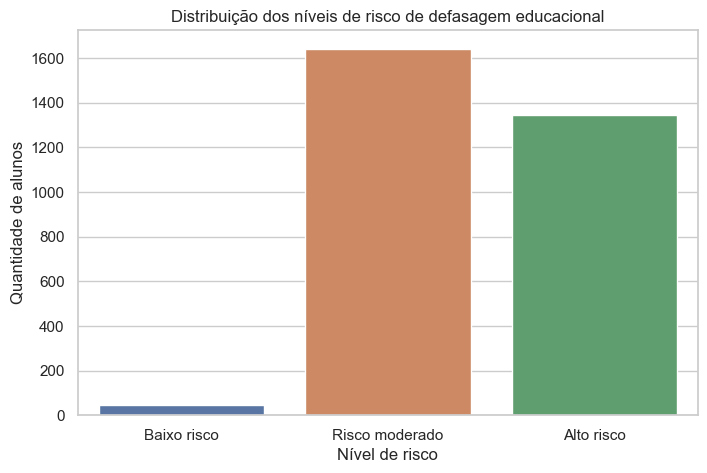

In [148]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="nivel_risco", order=["Baixo risco","Risco moderado","Alto risco"])

plt.title("Distribuição dos níveis de risco de defasagem educacional")
plt.xlabel("Nível de risco")
plt.ylabel("Quantidade de alunos")

plt.show()

# O gráfico apresenta a distribuição dos alunos de acordo com os níveis de risco de defasagem educacional definidos a partir do indicador IAN. Observa-se que a maior parte dos alunos se encontra nos níveis de risco moderado e alto, enquanto apenas uma pequena parcela apresenta baixo risco de defasagem educacional.

## 4. Análise exploratória

c:\Users\kurata2\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\kurata2\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\kurata2\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


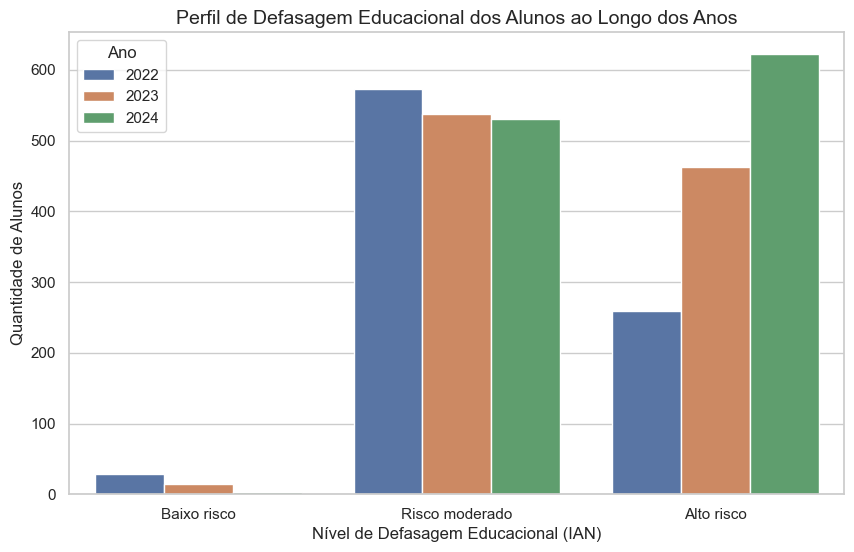

In [ ]:
# -------------------------------------------------------------
# Análise do Perfil de Defasagem dos Alunos
# Indicador: IAN (Indicador de Adequação de Nível)
# -------------------------------------------------------------

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="nivel_risco",   # já criamos essa variável anteriormente
    hue="ano",
    order=[
        "Baixo risco",
        "Risco moderado",
        "Alto risco"
    ]
)

plt.title("Perfil de Defasagem Educacional dos Alunos ao Longo dos Anos", fontsize=14)
plt.xlabel("Nível de Defasagem Educacional (IAN)")
plt.ylabel("Quantidade de Alunos")

plt.legend(title="Ano")

plt.show()

# O gráfico apresenta a distribuição dos alunos de acordo com os níveis de defasagem educacional definidos pelo indicador IAN ao longo dos anos analisados. Observa-se que a maior parte dos alunos encontra-se no nível de risco moderado, indicando que muitos estudantes apresentam algum grau de defasagem educacional. Também é possível observar um aumento no número de alunos classificados no nível de alto risco nos anos mais recentes, o que pode indicar desafios educacionais adicionais enfrentados pelos estudantes ao longo do período analisado.


c:\Users\kurata2\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\kurata2\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\kurata2\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\kurata2\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

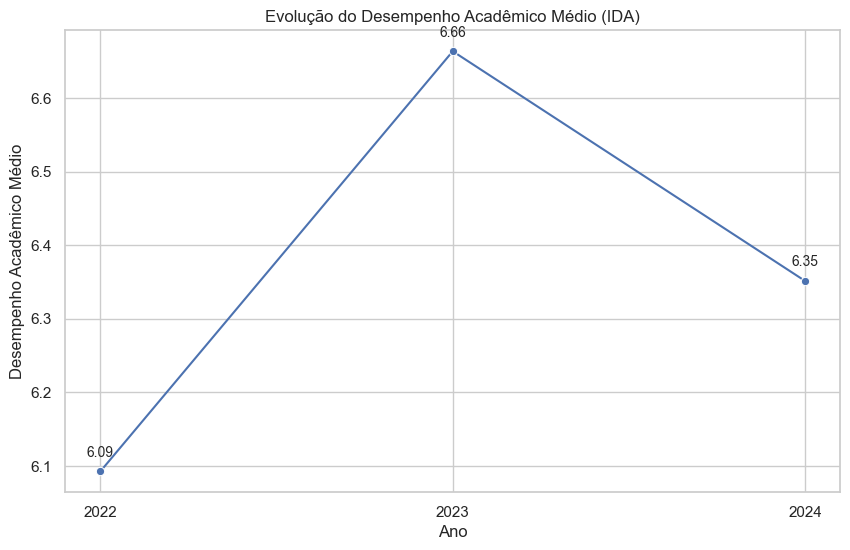

In [152]:
# -------------------------------------------------------------
# Evolução do desempenho acadêmico (IDA) ao longo dos anos
# -------------------------------------------------------------

# garantir que o ano seja inteiro
df["ano"] = df["ano"].astype(int)

# calcular média do IDA por ano
media_ida = df.groupby("ano", as_index=False)["ida"].mean()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=media_ida,
    x="ano",
    y="ida",
    marker="o"
)

# adicionar valores no gráfico
for i, row in media_ida.iterrows():
    plt.text(
        row["ano"],
        row["ida"] + 0.02,
        round(row["ida"],2),
        horizontalalignment="center",
        fontsize=10
    )

plt.title("Evolução do Desempenho Acadêmico Médio (IDA)")
plt.xlabel("Ano")
plt.ylabel("Desempenho Acadêmico Médio")

plt.xticks([2022, 2023, 2024])

plt.show()

# O gráfico apresenta a evolução do desempenho acadêmico médio dos alunos ao longo dos anos analisados, utilizando o indicador IDA. Observa-se um aumento no desempenho médio entre 2022 e 2023, indicando possível melhora no desempenho educacional nesse período. Em 2024 ocorre uma leve redução, porém o desempenho médio ainda permanece superior ao observado em 2022.

c:\Users\kurata2\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\kurata2\anaconda3\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


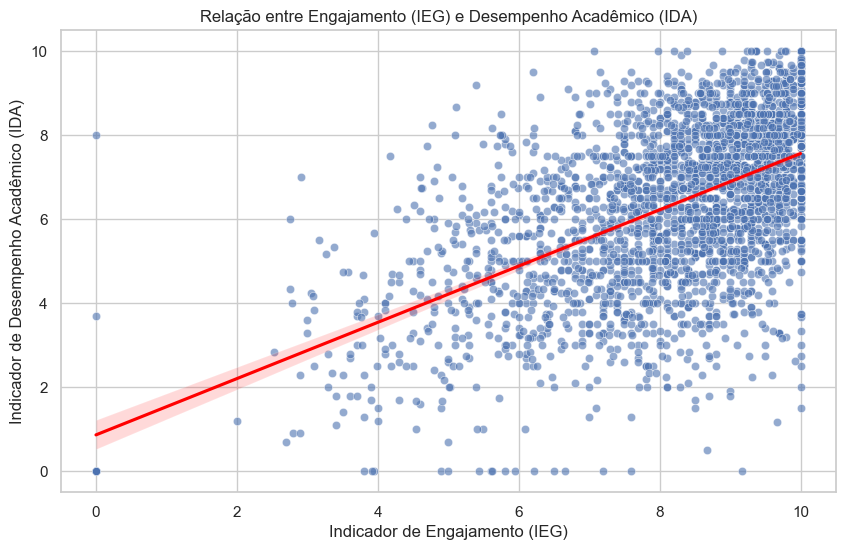

In [153]:
# -------------------------------------------------------------
# Relação entre engajamento (IEG) e desempenho acadêmico (IDA)
# -------------------------------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="ieg",
    y="ida",
    alpha=0.6
)

# linha de tendência
sns.regplot(
    data=df,
    x="ieg",
    y="ida",
    scatter=False,
    color="red"
)

plt.title("Relação entre Engajamento (IEG) e Desempenho Acadêmico (IDA)")
plt.xlabel("Indicador de Engajamento (IEG)")
plt.ylabel("Indicador de Desempenho Acadêmico (IDA)")

plt.show()

# O gráfico apresenta a relação entre o indicador de engajamento dos alunos (IEG) e o indicador de desempenho acadêmico (IDA). Observa-se uma tendência positiva entre as variáveis, indicando que alunos mais engajados nas atividades educacionais tendem a apresentar melhor desempenho acadêmico. Entretanto, também é possível observar certa dispersão entre os pontos, sugerindo que outros fatores educacionais e psicossociais também influenciam o desempenho dos estudantes.

In [154]:
df[["ieg","ida"]].corr()

,ieg,ida
ieg,1.000000,0.539057
ida,0.539057,1.000000


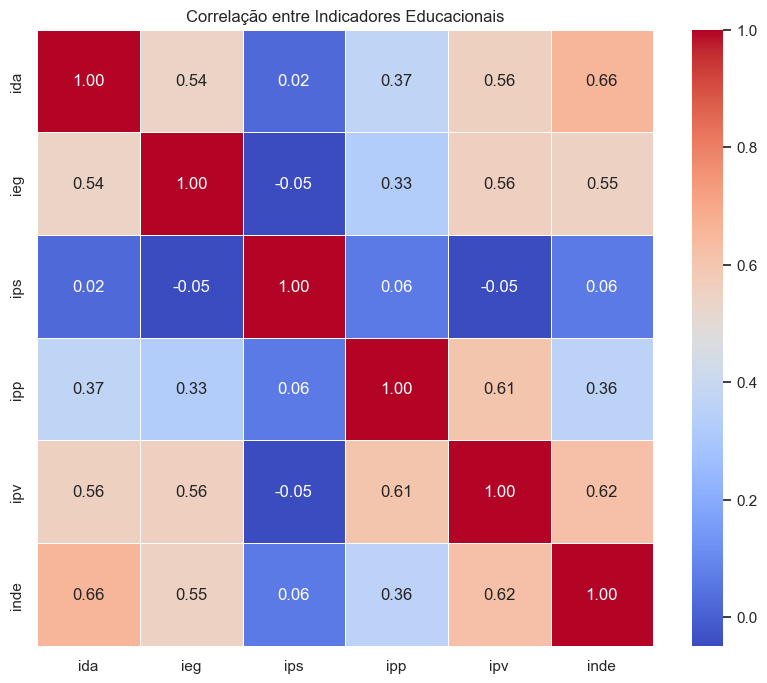

In [155]:
# -------------------------------------------------------------
# Correlação entre indicadores educacionais
# -------------------------------------------------------------

plt.figure(figsize=(10,8))

cols = ["ida", "ieg", "ips", "ipp", "ipv", "inde"]

corr = df[cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlação entre Indicadores Educacionais")

plt.show()

# O heatmap apresenta a correlação entre os principais indicadores educacionais analisados no estudo. Observa-se que o indicador geral de desempenho (INDE) apresenta maior correlação com o desempenho acadêmico (IDA), seguido pelo indicador de ponto de virada educacional (IPV) e pelo nível de engajamento dos alunos (IEG). Esses resultados sugerem que fatores relacionados ao desempenho acadêmico e ao engajamento nas atividades educacionais possuem influência significativa no desenvolvimento educacional dos alunos.


## 5. Modelos de Machine Learning

In [126]:
# -------------------------------------------------------------
# Importação das bibliotecas para Machine Learning
# -------------------------------------------------------------

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [156]:
# -------------------------------------------------------------
# Preparação dos dados para Machine Learning
# -------------------------------------------------------------

# Variáveis explicativas (features)
features = ["ida", "ieg", "ips", "ipp", "ipv"]

# Seleção das variáveis explicativas
X = df[features].copy()

# tratar valores ausentes
X = X.fillna(0)

# Variável alvo (risco de defasagem)
y = df["risco_defasagem"]

# -------------------------------------------------------------
# Separação dos dados em treino e teste
# -------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,      # 70% treino / 30% teste
    random_state=42,    # reprodutibilidade
    stratify=y          # mantém proporção das classes
)

# # -------------------------------------------------------------
# Preparação dos dados para Machine Learning
# -------------------------------------------------------------

# Variáveis explicativas (features)
features = ["ida", "ieg", "ips", "ipp", "ipv"]

# Seleção das variáveis explicativas
X = df[features].copy()

# tratar valores ausentes
X = X.fillna(0)

# Variável alvo (risco de defasagem)
y = df["risco_defasagem"]

# -------------------------------------------------------------
# Separação dos dados em treino e teste
# -------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,      # 70% treino / 30% teste
    random_state=42,    # reprodutibilidade
    stratify=y          # mantém proporção das classes
)

# Para o treinamento do modelo preditivo, selecionamos como variáveis explicativas indicadores educacionais relacionados ao desempenho acadêmico, engajamento e aspectos psicopedagógicos dos alunos. Em seguida, os dados foram divididos em conjuntos de treino e teste, utilizando 70% das observações para treinamento do modelo e 30% para avaliação de desempenho

In [158]:
# -------------------------------------------------------------
# Modelo 1 – Regressão Logística
# -------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

# normalizar as variáveis
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# criar modelo
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# treinar modelo
log_model.fit(X_train_scaled, y_train)

# fazer previsões
log_pred = log_model.predict(X_test_scaled)

# avaliar modelo
log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", round(log_acc,3))

print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, log_pred))

# O primeiro modelo utilizado foi a regressão logística. Esse modelo apresentou desempenho moderado na identificação de alunos com risco de defasagem educacional.

Logistic Regression Accuracy: 0.525

Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.51      0.54       506
           1       0.47      0.55      0.50       403

    accuracy                           0.52       909
   macro avg       0.53      0.53      0.52       909
weighted avg       0.53      0.52      0.53       909


Confusion Matrix:

[[257 249]
 [183 220]]


In [160]:
# -------------------------------------------------------------
# Modelo 2 – Random Forest
# -------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

# Treinar modelo
rf_model.fit(X_train, y_train)

# Fazer previsões
rf_pred = rf_model.predict(X_test)

# Avaliar modelo
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_acc,3))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))

# O modelo Random Forest apresentou desempenho superior à regressão logística, indicando maior capacidade de capturar padrões entre os indicadores educacionais e o risco de defasagem. Esse modelo consegue lidar melhor com relações não lineares entre as variáveis, o que pode explicar seu melhor desempenho na tarefa de classificação.


Random Forest Accuracy: 0.638

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.77      0.70       506
           1       0.62      0.47      0.54       403

    accuracy                           0.64       909
   macro avg       0.63      0.62      0.62       909
weighted avg       0.64      0.64      0.63       909


Confusion Matrix:

[[390 116]
 [213 190]]


In [161]:
# -------------------------------------------------------------
# Comparação dos modelos
# -------------------------------------------------------------

if rf_acc > log_acc:
    best_model = "Random Forest"
    best_score = rf_acc
else:
    best_model = "Logistic Regression"
    best_score = log_acc

print("Melhor modelo:", best_model)
print("Accuracy do melhor modelo:", round(best_score,3))

Melhor modelo: Random Forest
Accuracy do melhor modelo: 0.638


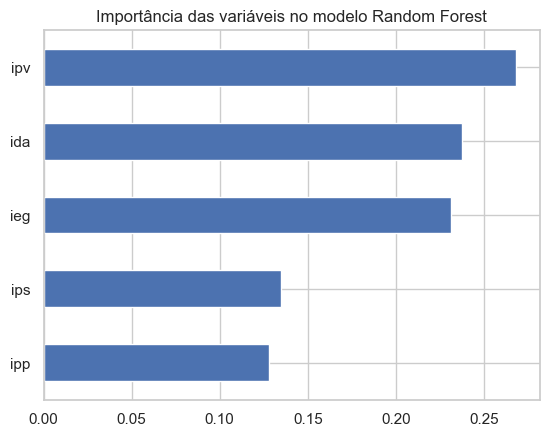

In [131]:
import pandas as pd

importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=features)

feat_imp.sort_values().plot(kind="barh")

plt.title("Importância das variáveis no modelo Random Forest")

plt.show()

# variáveis mais influenciam o modelo: desempenho acadêmico, engajamento e ponto de virada educacional

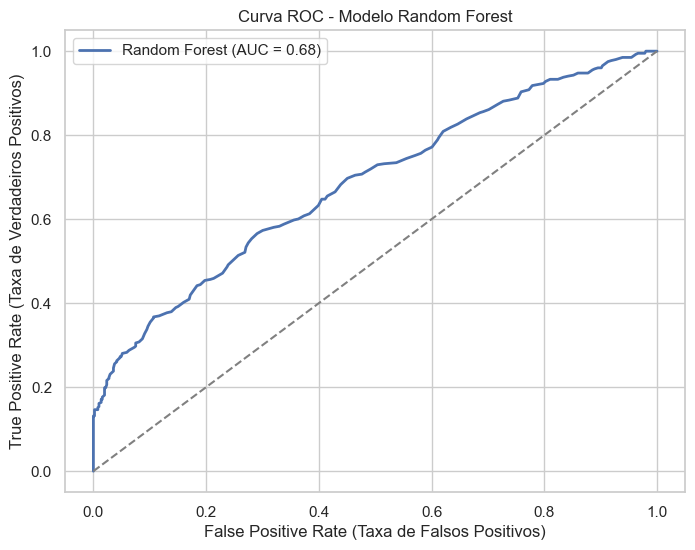

In [163]:
# -------------------------------------------------------------
# Curva ROC e AUC do modelo Random Forest
# -------------------------------------------------------------

from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidade da classe positiva (alto risco de defasagem)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

# calcular AUC
auc = roc_auc_score(y_test, rf_probs)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.2f})", linewidth=2)

# linha de referência (modelo aleatório)
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate (Taxa de Falsos Positivos)")
plt.ylabel("True Positive Rate (Taxa de Verdadeiros Positivos)")

plt.title("Curva ROC - Modelo Random Forest")

plt.legend()

plt.show()

# A curva ROC foi utilizada para avaliar a capacidade do modelo Random Forest em distinguir alunos com alto risco de defasagem educacional. O valor de AUC indica que o modelo apresenta capacidade moderada de separação entre as classes, sugerindo que os indicadores educacionais analisados possuem relação com o risco de defasagem, embora não expliquem completamente o fenômeno.

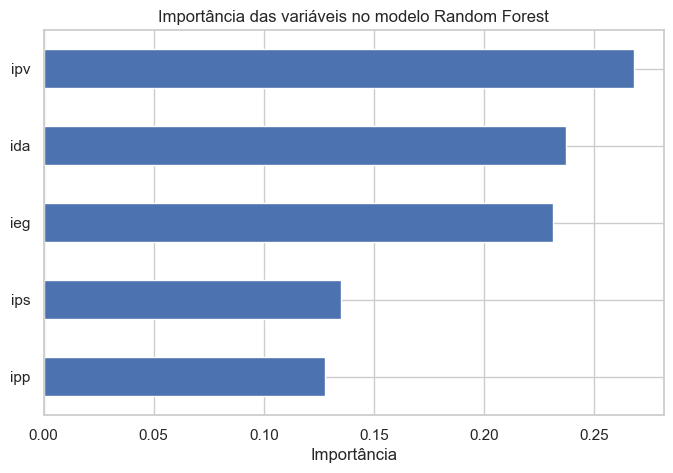

In [ ]:
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=features)

feat_imp.sort_values().plot(kind="barh")

plt.title("Importância das variáveis no modelo Random Forest")

plt.xlabel("Importância")

plt.show()

In [ ]:
#Exportar modelo

import joblib

joblib.dump(rf_model, "modelo_random_forest.pkl")

['modelo_random_forest.pkl']


# 6. Insights e Recomendações

## Insights a partir da análise dos dados

A análise exploratória dos dados permitiu compreender padrões importantes relacionados ao desempenho educacional dos alunos atendidos pelo programa Passos Mágicos. Observamos que grande parte dos alunos apresenta níveis moderados ou elevados de defasagem educacional, indicando a relevância do acompanhamento pedagógico realizado pelo programa.

Ao analisar a evolução do desempenho acadêmico ao longo dos anos, verificamos que houve melhora entre 2022 e 2023, seguida por uma leve redução em 2024. Apesar dessa variação, os resultados permanecem superiores aos níveis observados no início da série analisada.

Também identificamos uma relação positiva entre o engajamento dos alunos nas atividades educacionais e seu desempenho acadêmico. Alunos com maiores níveis de engajamento tendem a apresentar melhores resultados acadêmicos, reforçando a importância de estratégias que incentivem a participação ativa nas atividades do programa.

A análise de correlação entre os indicadores educacionais mostrou que o desempenho acadêmico (IDA), o engajamento (IEG) e o indicador de ponto de virada educacional (IPV) apresentam maior relação com o indicador geral de desempenho (INDE). Isso sugere que esses fatores desempenham papel relevante no desenvolvimento educacional dos estudantes.


## Insights do modelo preditivo

O modelo Random Forest apresentou melhor desempenho na previsão do risco de defasagem educacional quando comparado à regressão logística. Esse resultado indica que o modelo possui maior capacidade de capturar relações complexas entre os indicadores educacionais analisados.

Apesar do desempenho moderado do modelo, ele demonstra potencial para identificar alunos com maior probabilidade de apresentar defasagem educacional severa. Isso permite que a instituição antecipe intervenções pedagógicas e ofereça suporte adicional aos alunos com maior necessidade de acompanhamento.

## Recomendações para a Passos Mágicos

Com base nos resultados obtidos na análise dos dados e na modelagem preditiva, algumas ações podem ser sugeridas para potencializar os resultados do programa educacional:

Intensificar estratégias de engajamento dos alunos nas atividades educacionais, uma vez que o engajamento demonstrou relação direta com o desempenho acadêmico.

Monitorar de forma mais próxima alunos classificados com maior risco de defasagem educacional.

Utilizar os indicadores educacionais de forma integrada para identificar precocemente possíveis dificuldades de aprendizagem.

Implementar o modelo preditivo em uma aplicação de dados que permita acompanhar o risco educacional dos alunos ao longo do tempo.

Essas iniciativas podem contribuir para melhorar os resultados educacionais dos alunos atendidos pelo programa e apoiar a tomada de decisão baseada em dados.